<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/production/production_technology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Production technology with NeqSim

A worked introduction to the surface-production chain from a multiphase well stream through pressure control, primary separation, gas cooling, liquid knock-out, and export compression. The notebook is intended for senior undergraduate, graduate, and early-career production/process engineers.

In [1]:
import importlib.util, subprocess, sys
if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim==3.16.0"])
from importlib.metadata import version
import json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from neqsim.thermo import fluid, TPflash
from neqsim.process import clearProcess, stream, valve, separator, cooler, compressor, runProcess
NEQSIM_VERSION = version("neqsim")
print(f"NeqSim {NEQSIM_VERSION}; Python {sys.version.split()[0]}")

NeqSim 3.16.0; Python 3.12.13


## Learning objectives and prerequisites

You should already recognize pressure, temperature, flow rate, phase equilibrium, and steady-state material and energy balances. After completing the notebook you should be able to: (1) translate a production-system sketch into connected NeqSim objects; (2) explain why a choke is approximately isenthalpic; (3) quantify gas/liquid separation and compressor duty; (4) test pressure, temperature, and throughput sensitivities; and (5) distinguish screening results from equipment design.

In [2]:
case = {
    "well_pressure_bara": 150.0, "well_temperature_C": 80.0,
    "feed_kg_per_h": 10_000.0, "separator_pressure_bara": 60.0,
    "gas_cooler_outlet_C": 30.0, "export_pressure_bara": 120.0,
    "compressor_isentropic_efficiency": 0.78
}
composition_mol_percent = {
    "nitrogen": 1.0, "CO2": 2.0, "methane": 70.0, "ethane": 7.0,
    "propane": 5.0, "i-butane": 1.5, "n-butane": 2.0,
    "i-pentane": 1.0, "n-pentane": 1.0, "n-hexane": 2.5,
    "n-heptane": 2.5, "n-octane": 2.0, "n-nonane": 1.0, "nC10": 1.5
}
assert abs(sum(composition_mol_percent.values()) - 100.0) < 1e-12
pd.Series(case, name="value").to_frame()

,value
well_pressure_bara,150.00
well_temperature_C,80.00
feed_kg_per_h,10000.00
separator_pressure_bara,60.00
gas_cooler_outlet_C,30.00
export_pressure_bara,120.00
compressor_isentropic_efficiency,0.78


## Control volumes and governing balances

For a steady unit without reaction, total mass obeys $\sum \dot m_{in}=\sum \dot m_{out}$. A steady-flow energy balance is $\dot Q-\dot W_s=\sum_{out}\dot m(h+v^2/2+gz)-\sum_{in}\dot m(h+v^2/2+gz)$. This screening model neglects kinetic and potential terms. The separator has no imposed heat or shaft work; the cooler imposes heat removal; the compressor receives shaft work.

In [3]:
def make_well_fluid(flow_kg_h=case["feed_kg_per_h"]):
    f = fluid("pr")
    for component, amount in composition_mol_percent.items():
        f.addComponent(component, amount)
    f.setMixingRule("classic")
    f.setMultiPhaseCheck(True)
    f.setTemperature(case["well_temperature_C"], "C")
    f.setPressure(case["well_pressure_bara"], "bara")
    f.setTotalFlowRate(flow_kg_h, "kg/hr")
    TPflash(f)
    f.initProperties()
    return f
well_fluid = make_well_fluid()
print(f"Feed phases: {well_fluid.getNumberOfPhases()} | density: {well_fluid.getDensity('kg/m3'):.2f} kg/m3")

Feed phases: 2 | density: 210.50 kg/m3


## How NeqSim represents the problem

`fluid('pr')` creates a Peng–Robinson thermodynamic system. Components, mixing rule, state, and flow rate belong to that system. `TPflash` minimizes the appropriate thermodynamic potential subject to phase and component balances. A process `stream` carries a thermodynamic system between unit operations. Each downstream unit obtains an outlet stream, so the Python graph mirrors the physical flowsheet. `runProcess()` asks NeqSim's Java process-system solver to execute the connected units in dependency order.

In [4]:
feed_properties = pd.Series({
    "pressure [bara]": well_fluid.getPressure("bara"),
    "temperature [degC]": well_fluid.getTemperature("C"),
    "mass flow [kg/h]": well_fluid.getFlowRate("kg/hr"),
    "molar mass [kg/mol]": well_fluid.getMolarMass(),
    "density [kg/m3]": well_fluid.getDensity("kg/m3"),
    "specific enthalpy [J/kg]": well_fluid.getEnthalpy("J/kg"),
    "number of phases [-]": well_fluid.getNumberOfPhases(),
}, name="feed")
feed_properties.to_frame()

,feed
pressure [bara],150.000000
temperature [degC],80.000000
mass flow [kg/h],10000.000000
molar mass [kg/mol],0.030539
density [kg/m3],210.503228
specific enthalpy [J/kg],-55385.731236
number of phases [-],2.000000


## Base production topology

The well stream is throttled from 150 to 60 bara, flashed in a first-stage separator, and the gas is cooled to 30 °C. A scrubber removes condensed liquid before compression to 120 bara. This is deliberately compact: real facilities may include several separation and compression stages, produced-water treatment, chemical injection, metering, relief systems, controls, and export hydraulics.

In [5]:
def build_and_run(separator_pressure_bara=60.0, cooler_outlet_C=30.0, feed_kg_h=10_000.0):
    clearProcess()
    feed = stream("well feed", make_well_fluid(feed_kg_h))
    choke = valve("production choke", feed)
    choke.setOutletPressure(separator_pressure_bara, "bara")
    first_separator = separator("first-stage separator", choke.getOutStream())
    gas_cooler = cooler("gas cooler", first_separator.getGasOutStream())
    gas_cooler.setOutTemperature(cooler_outlet_C, "C")
    scrubber = separator("compressor scrubber", gas_cooler.getOutStream())
    export_compressor = compressor("export compressor", scrubber.getGasOutStream())
    export_compressor.setOutletPressure(case["export_pressure_bara"], "bara")
    export_compressor.setIsentropicEfficiency(case["compressor_isentropic_efficiency"])
    runProcess()
    return {"feed": feed, "choke": choke, "separator": first_separator,
            "cooler": gas_cooler, "scrubber": scrubber, "compressor": export_compressor}
base = build_and_run()
print("Base process solved.")

Base process solved.


## Material balance and stream interpretation

The first separator creates a gas product and a hydrocarbon-liquid product at a common equilibrium temperature and pressure. Cooling the gas may condense more heavy components, which the scrubber removes. The overall production-system balance therefore compares feed with export gas plus both liquid outlets. A small relative residual is a stronger check than simply observing that the process ran.

In [6]:
named_streams = {
    "well feed": base["feed"],
    "after choke": base["choke"].getOutStream(),
    "separator gas": base["separator"].getGasOutStream(),
    "separator liquid": base["separator"].getLiquidOutStream(),
    "export gas": base["scrubber"].getGasOutStream(),
    "scrubber liquid": base["scrubber"].getLiquidOutStream(),
}
stream_table = pd.DataFrame({name: {
    "mass flow [kg/h]": s.getFlowRate("kg/hr"),
    "temperature [degC]": s.getTemperature("C"),
    "pressure [bara]": s.getPressure("bara"),
} for name, s in named_streams.items()}).T
m_in = stream_table.loc["well feed", "mass flow [kg/h]"]
m_out = stream_table.loc[["separator liquid", "export gas", "scrubber liquid"], "mass flow [kg/h]"].sum()
mass_balance_error = (m_out - m_in) / m_in
display(stream_table.round(3))
print(f"Overall relative mass-balance error: {mass_balance_error:.3e}")

Overall relative mass-balance error: 2.328e-14


,mass flow [kg/h],temperature [degC],pressure [bara]
well feed,10000.000,80.000,150.0
after choke,10000.000,63.649,60.0
separator gas,5806.856,63.649,60.0
separator liquid,4193.144,63.649,60.0
export gas,5444.279,30.000,60.0
scrubber liquid,362.577,30.000,60.0


## Throttling and Joule–Thomson cooling

For an insulated valve with negligible kinetic and potential changes and no shaft work, $h_{out}\approx h_{in}$. Temperature is not fixed: it follows from the outlet-pressure PH flash and the fluid's real-gas behavior. Cooling and phase formation are therefore consequences of the EOS, composition, and pressure reduction—not an imposed temperature drop.

In [7]:
h_in = base["feed"].getFluid().getEnthalpy("J/kg")
h_out = base["choke"].getOutStream().getFluid().getEnthalpy("J/kg")
choke_enthalpy_residual = (h_out - h_in) / max(abs(h_in), 1.0)
choke_delta_T = base["choke"].getOutStream().getTemperature("C") - base["feed"].getTemperature("C")
pd.Series({
    "inlet enthalpy [J/kg]": h_in, "outlet enthalpy [J/kg]": h_out,
    "relative enthalpy residual [-]": choke_enthalpy_residual,
    "temperature change [K]": choke_delta_T
}).to_frame("value")

,value
inlet enthalpy [J/kg],-5.538573e+04
outlet enthalpy [J/kg],-5.538573e+04
relative enthalpy residual [-],2.661476e-10
temperature change [K],-1.635095e+01


## Phase equilibrium and component routing

At equilibrium, each component has equal fugacity in coexisting phases. Volatile components preferentially enter the gas, while heavier hydrocarbons preferentially enter the liquid. The stream compositions below use NeqSim's component inventory after each flash. They are not fixed split fractions; they respond to pressure, temperature, and feed composition.

In [8]:
selected_components = ["methane", "ethane", "propane", "n-hexane", "nC10"]
gas_fluid = base["separator"].getGasOutStream().getFluid()
liquid_fluid = base["separator"].getLiquidOutStream().getFluid()
split_composition = pd.DataFrame({
    "feed mole fraction [-]": [well_fluid.getComponent(c).getz() for c in selected_components],
    "separator gas mole fraction [-]": [gas_fluid.getComponent(c).getz() for c in selected_components],
    "separator liquid mole fraction [-]": [liquid_fluid.getComponent(c).getz() for c in selected_components],
}, index=selected_components)
split_composition.round(5)

,feed mole fraction [-],separator gas mole fraction [-],separator liquid mole fraction [-]
methane,0.700,0.80546,0.20184
ethane,0.070,0.07242,0.05856
propane,0.050,0.04372,0.07969
n-hexane,0.025,0.00619,0.11384
nC10,0.015,0.00028,0.08455


## Compression theory and NeqSim calculation

An ideal-gas screening expression is $w_s=\frac{k}{k-1}\frac{ZRT_1}{M}[(p_2/p_1)^{(k-1)/k}-1]$. Actual shaft power is approximately $\dot W=\dot m w_s/\eta_s$. NeqSim instead performs an EOS-based isentropic calculation and applies the specified efficiency, retaining mixture properties and real-gas effects. Comparing the two is a useful order-of-magnitude check, not a benchmark.

In [9]:
suction = base["scrubber"].getGasOutStream().getFluid()
suction.initProperties()
k = suction.getGamma2()
Z = suction.getZ()
T1_K = suction.getTemperature()
MW = suction.getMolarMass()
ratio = case["export_pressure_bara"] / suction.getPressure("bara")
m_dot = base["scrubber"].getGasOutStream().getFlowRate("kg/hr") / 3600.0
ideal_screen_W = m_dot * k/(k-1) * Z*8.314462618*T1_K/MW * (ratio**((k-1)/k)-1) / case["compressor_isentropic_efficiency"]
neqsim_power_W = base["compressor"].getPower()
compressor_results = pd.Series({
    "pressure ratio [-]": ratio, "suction Z [-]": Z, "suction k [-]": k,
    "NeqSim power [MW]": neqsim_power_W/1e6, "ideal-gas screen [MW]": ideal_screen_W/1e6,
    "discharge temperature [degC]": base["compressor"].getOutStream().getTemperature("C"),
})
compressor_results.to_frame("value").round(4)

,value
pressure ratio [-],2.0000
suction Z [-],0.8197
suction k [-],1.1863
NeqSim power [MW],0.1471
ideal-gas screen [MW],0.1422
discharge temperature [degC],88.6174


## Separator-pressure sensitivity

Lower first-stage pressure normally flashes more gas and can increase recompression duty; higher pressure retains more light components in the liquid but reduces the compressor pressure ratio. The optimum is system-specific because downstream oil stabilization, gas specifications, well deliverability, and equipment limits interact. We vary only one pressure while holding feed state, cooler outlet, export pressure, and efficiency fixed.

In [10]:
pressure_rows = []
for p_sep in [40.0, 50.0, 60.0, 70.0, 80.0]:
    model = build_and_run(separator_pressure_bara=p_sep)
    pressure_rows.append({
        "separator pressure [bara]": p_sep,
        "first-stage gas [kg/h]": model["separator"].getGasOutStream().getFlowRate("kg/hr"),
        "export gas [kg/h]": model["scrubber"].getGasOutStream().getFlowRate("kg/hr"),
        "compressor power [MW]": model["compressor"].getPower()/1e6,
        "choke outlet temperature [degC]": model["choke"].getOutStream().getTemperature("C"),
    })
pressure_sensitivity = pd.DataFrame(pressure_rows)
pressure_sensitivity.round(3)

,separator pressure [bara],first-stage gas [kg/h],export gas [kg/h],compressor power [MW],choke outlet temperature [degC]
0,40.0,5943.842,5684.782,0.265,57.394
1,50.0,5865.085,5554.633,0.198,60.746
2,60.0,5806.856,5444.279,0.147,63.649
3,70.0,5763.844,5347.969,0.108,66.220
4,80.0,5733.072,5262.470,0.076,68.530


## Gas-cooling sensitivity

Cooling upstream of a compressor reduces specific compression work but may condense hydrocarbons or water. The scrubber protects the compressor from liquid carry-over. This sweep shows both effects: gas available to the compressor and required power change together. Hydrate formation, cooling-medium limits, and hydrocarbon dew-point specifications require separate checks in a design study.

In [11]:
temperature_rows = []
for t_cool in [15.0, 25.0, 30.0, 40.0, 50.0]:
    model = build_and_run(cooler_outlet_C=t_cool)
    temperature_rows.append({
        "cooler outlet [degC]": t_cool,
        "scrubber liquid [kg/h]": model["scrubber"].getLiquidOutStream().getFlowRate("kg/hr"),
        "export gas [kg/h]": model["scrubber"].getGasOutStream().getFlowRate("kg/hr"),
        "compressor power [MW]": model["compressor"].getPower()/1e6,
        "cooler duty [MW]": model["cooler"].getDuty()/1e6,
    })
temperature_sensitivity = pd.DataFrame(temperature_rows)
temperature_sensitivity.round(3)

,cooler outlet [degC],scrubber liquid [kg/h],export gas [kg/h],compressor power [MW],cooler duty [MW]
0,15.0,592.051,5214.805,0.134,-0.234
1,25.0,434.144,5372.712,0.143,-0.183
2,30.0,362.577,5444.279,0.147,-0.158
3,40.0,232.280,5574.576,0.156,-0.109
4,50.0,118.956,5687.900,0.164,-0.062


## Throughput and capacity screening

At fixed inlet state and fixed equipment specifications, phase fractions should remain nearly constant and extensive quantities such as duty and power should scale approximately with flow. Real equipment does not scale indefinitely: compressor maps, valve capacity, separator residence time, piping pressure drop, heat-transfer area, and control ranges eventually govern. The proportionality test below checks model consistency while illustrating why capacity studies need explicit equipment constraints.

In [12]:
rate_rows = []
for flow in [5_000.0, 7_500.0, 10_000.0, 12_500.0, 15_000.0]:
    model = build_and_run(feed_kg_h=flow)
    rate_rows.append({
        "feed [kg/h]": flow,
        "export gas [kg/h]": model["scrubber"].getGasOutStream().getFlowRate("kg/hr"),
        "compressor power [MW]": model["compressor"].getPower()/1e6,
        "specific power [kWh/t feed]": model["compressor"].getPower()/1e3/(flow/1000.0),
    })
rate_sensitivity = pd.DataFrame(rate_rows)
rate_sensitivity.round(4)

,feed [kg/h],export gas [kg/h],compressor power [MW],specific power [kWh/t feed]
0,5000.0,2722.1395,0.0736,14.7116
1,7500.0,4083.2092,0.1103,14.7116
2,10000.0,5444.2790,0.1471,14.7116
3,12500.0,6805.3487,0.1839,14.7116
4,15000.0,8166.4185,0.2207,14.7116


## First-stage separator sizing screen

A common gravity-separation screen uses the Souders–Brown relation $v_{max}=K\sqrt{(\rho_L-\rho_G)/\rho_G}$. With actual gas volumetric flow $Q_G$, required disengagement area is $A=Q_G/v_{max}$. Here $K=0.10$ m/s and a 20% diameter margin are illustrative assumptions—not a substitute for applicable company criteria, droplet-size calculations, internals selection, liquid residence time, surge volume, nozzle design, or mechanical design.

In [13]:
base = build_and_run()  # restore the documented base case after the sweeps
gas_out = base["separator"].getGasOutStream()
liq_out = base["separator"].getLiquidOutStream()
rho_g = gas_out.getFluid().getDensity("kg/m3")
rho_l = liq_out.getFluid().getDensity("kg/m3")
q_g = gas_out.getFlowRate("m3/sec")
K_sb = 0.10
v_allow = K_sb * math.sqrt((rho_l-rho_g)/rho_g)
area_required = q_g/v_allow
diameter_with_margin = 1.20*math.sqrt(4.0*area_required/math.pi)
separator_screen = pd.Series({
    "gas density [kg/m3]": rho_g, "liquid density [kg/m3]": rho_l,
    "actual gas flow [m3/s]": q_g, "allowable gas velocity [m/s]": v_allow,
    "required gas area [m2]": area_required, "screening diameter incl. margin [m]": diameter_with_margin
})
separator_screen.to_frame("value").round(4)

,value
gas density [kg/m3],52.4568
liquid density [kg/m3],576.5323
actual gas flow [m3/s],0.0307
allowable gas velocity [m/s],0.3161
required gas area [m2],0.0973
screening diameter incl. margin [m],0.4223


## Product indicators, boundaries, and validity limits

The indicators below summarize yields and energy intensity; they are not sales specifications. A real study must check water and hydrocarbon dew points, H2S/CO2, heating value, oil vapor pressure, BS&W, salt, export pressure/temperature, emissions, availability, turndown, start-up, shutdown, relief, and dynamic operability. The PR EOS is appropriate for a hydrocarbon screening case, but fluid characterization and binary-interaction tuning should be reviewed against PVT data.

In [14]:
feed_mass = base["feed"].getFlowRate("kg/hr")
export_mass = base["scrubber"].getGasOutStream().getFlowRate("kg/hr")
liquid_mass = (base["separator"].getLiquidOutStream().getFlowRate("kg/hr") +
               base["scrubber"].getLiquidOutStream().getFlowRate("kg/hr"))
export_methane = base["scrubber"].getGasOutStream().getFluid().getComponent("methane").getz()
indicators = pd.Series({
    "export-gas mass yield [-]": export_mass/feed_mass,
    "total-liquid mass yield [-]": liquid_mass/feed_mass,
    "export-gas methane mole fraction [-]": export_methane,
    "compressor energy intensity [kWh/t feed]": base["compressor"].getPower()/1e3/(feed_mass/1000.0),
    "cooler heat removed [MW]": -base["cooler"].getDuty()/1e6,
})
indicators.to_frame("value").round(5)

,value
export-gas mass yield [-],0.54443
total-liquid mass yield [-],0.45557
export-gas methane mole fraction [-],0.81879
compressor energy intensity [kWh/t feed],14.71157
cooler heat removed [MW],0.15782


## Visual engineering interpretation

Plots are most useful when they expose coupled effects. The left panel shows how separator pressure changes gas recovery and power. The right panel shows how cooler temperature changes condensate knock-out and compression power. Trends, not isolated numbers, support operating-window discussions; a design decision still requires constraints and uncertainty ranges.

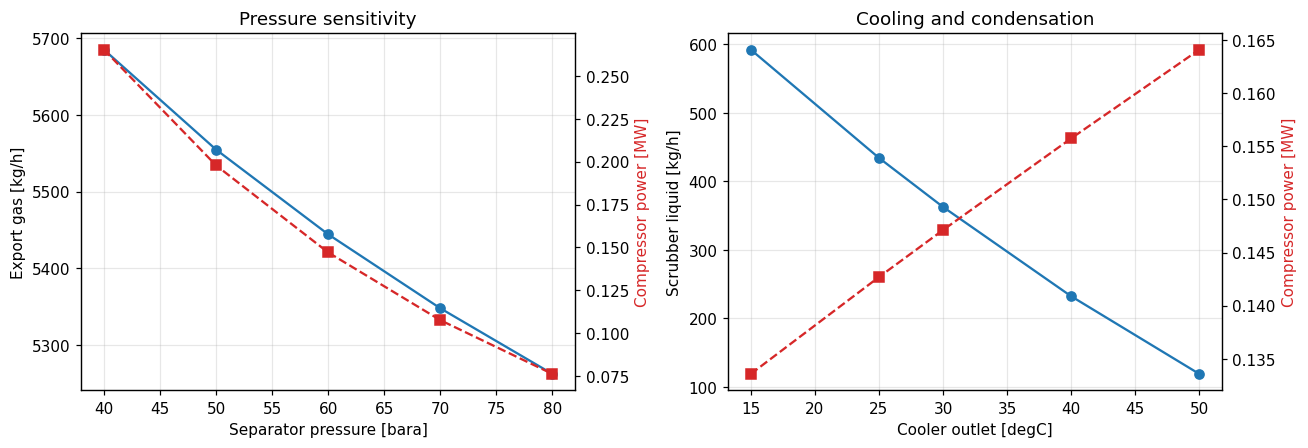

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
ax.plot(pressure_sensitivity["separator pressure [bara]"], pressure_sensitivity["export gas [kg/h]"], "o-", label="export gas [kg/h]")
ax.set(xlabel="Separator pressure [bara]", ylabel="Export gas [kg/h]", title="Pressure sensitivity")
ax.grid(True, alpha=0.3)
ax2 = ax.twinx(); ax2.plot(pressure_sensitivity["separator pressure [bara]"], pressure_sensitivity["compressor power [MW]"], "s--", color="tab:red", label="power")
ax2.set_ylabel("Compressor power [MW]", color="tab:red")
ax = axes[1]
ax.plot(temperature_sensitivity["cooler outlet [degC]"], temperature_sensitivity["scrubber liquid [kg/h]"], "o-")
ax.set(xlabel="Cooler outlet [degC]", ylabel="Scrubber liquid [kg/h]", title="Cooling and condensation")
ax.grid(True, alpha=0.3)
ax2 = ax.twinx(); ax2.plot(temperature_sensitivity["cooler outlet [degC]"], temperature_sensitivity["compressor power [MW]"], "s--", color="tab:red")
ax2.set_ylabel("Compressor power [MW]", color="tab:red")
fig.tight_layout(); plt.show()

## Verification and troubleshooting

The assertions test composition closure, pressures, mass conservation, isenthalpic throttling, physically ordered densities, positive equipment loads, component enrichment, and throughput scaling. If a case fails, check component names and units first; then confirm `setMixingRule`, `setMultiPhaseCheck`, the order of unit connections, and that `runProcess()` was called after every changed input. Near a phase boundary, small input changes can legitimately produce large changes in liquid rate.

In [16]:
checks = {
    "composition closes": abs(sum(composition_mol_percent.values())-100.0) < 1e-12,
    "choke reaches set pressure": abs(base["choke"].getOutStream().getPressure("bara")-60.0) < 1e-6,
    "overall mass closes": abs((export_mass+liquid_mass-feed_mass)/feed_mass) < 1e-8,
    "choke is isenthalpic": abs(choke_enthalpy_residual) < 1e-6,
    "liquid denser than gas": rho_l > rho_g > 0.0,
    "positive compressor power": base["compressor"].getPower() > 0.0,
    "cooler removes heat": base["cooler"].getDuty() < 0.0,
    "methane enriched in gas": split_composition.loc["methane", "separator gas mole fraction [-]"] > split_composition.loc["methane", "separator liquid mole fraction [-]"],
    "nC10 enriched in liquid": split_composition.loc["nC10", "separator liquid mole fraction [-]"] > split_composition.loc["nC10", "separator gas mole fraction [-]"],
    "screening power agrees within 35 percent": abs(ideal_screen_W-neqsim_power_W)/neqsim_power_W < 0.35,
    "specific power nearly rate invariant": rate_sensitivity["specific power [kWh/t feed]"].std()/rate_sensitivity["specific power [kWh/t feed]"].mean() < 1e-3,
}
for label, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}  {label}")
assert all(checks.values()), [name for name, passed in checks.items() if not passed]
print(f"All {len(checks)} engineering checks passed.")

PASS  composition closes
PASS  choke reaches set pressure
PASS  overall mass closes
PASS  choke is isenthalpic
PASS  liquid denser than gas
PASS  positive compressor power
PASS  cooler removes heat
PASS  methane enriched in gas
PASS  nC10 enriched in liquid
PASS  screening power agrees within 35 percent
PASS  specific power nearly rate invariant
All 11 engineering checks passed.


## Summary, exercises, and references

You constructed a compositional production model, verified its balances, and related NeqSim's PH flash, TP flashes, phase split, cooler, and compressor calculations to engineering theory. Suggested exercises: add water and a three-phase separator; introduce two-stage oil stabilization; add interstage compression; compare PR and SRK; fit the heavy end to PVT data; impose compressor-map and separator-capacity constraints; and connect a well or pipeline model.

References: NeqSim documentation and source ([equinor.github.io/neqsimhome](https://equinor.github.io/neqsimhome/)); GPSA Engineering Data Book, separation and compression sections; ISO 13703, *Design and installation of piping systems on offshore production platforms*; and Campbell, *Gas Conditioning and Processing*. Always apply the governing project standards and validated fluid data.

In [17]:
result_record = {
    "neqsim_version": NEQSIM_VERSION,
    "feed_kg_per_h": round(feed_mass, 3),
    "export_gas_kg_per_h": round(export_mass, 3),
    "liquid_products_kg_per_h": round(liquid_mass, 3),
    "compressor_power_MW": round(base["compressor"].getPower()/1e6, 5),
    "separator_screening_diameter_m": round(diameter_with_margin, 4),
    "validated_checks": len(checks),
}
print(json.dumps(result_record, indent=2))

{
  "neqsim_version": "3.16.0",
  "feed_kg_per_h": 10000.0,
  "export_gas_kg_per_h": 5444.279,
  "liquid_products_kg_per_h": 4555.721,
  "compressor_power_MW": 0.14712,
  "separator_screening_diameter_m": 0.4223,
  "validated_checks": 11
}
